In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Summarize messages

In [11]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware

agent = create_agent(
    model="gpt-4.1-nano",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            #trigger=("tokens", 100),
            #keep=("messages", 1)
        )
    ],
)

In [12]:
from langchain.messages import HumanMessage, AIMessage
from pprint import pprint

response = agent.invoke(
    {"messages": [
        HumanMessage(content="What is the capital of the moon?"),
        AIMessage(content="The capital of the moon is Lunapolis."),
        HumanMessage(content="What is the weather in Lunapolis?"),
        AIMessage(content="Skies are clear, with a high of 120C and a low of -100C."),
        HumanMessage(content="How many cheese miners live in Lunapolis?"),
        AIMessage(content="There are 100,000 cheese miners living in Lunapolis."),
        HumanMessage(content="Do you think the cheese miners' union will strike?"),
        AIMessage(content="Yes, because they are unhappy with the new president."),
        HumanMessage(content="If you were Lunapolis' new president how would you respond to the cheese miners' union?"),
        ]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

{'messages': [HumanMessage(content='What is the capital of the moon?', additional_kwargs={}, response_metadata={}, id='533b7e7a-a30e-4156-9500-aca4e4eae1e8'),
              AIMessage(content='The capital of the moon is Lunapolis.', additional_kwargs={}, response_metadata={}, id='a9c79695-05d5-405a-98a8-02d4521b19c5'),
              HumanMessage(content='What is the weather in Lunapolis?', additional_kwargs={}, response_metadata={}, id='bc29d981-4a67-416b-a06f-27bcbc8ca76a'),
              AIMessage(content='Skies are clear, with a high of 120C and a low of -100C.', additional_kwargs={}, response_metadata={}, id='4515e4d7-c595-4561-9087-943b21ccc516'),
              HumanMessage(content='How many cheese miners live in Lunapolis?', additional_kwargs={}, response_metadata={}, id='979c10a7-e94b-481b-a45f-ae004b8c46ea'),
              AIMessage(content='There are 100,000 cheese miners living in Lunapolis.', additional_kwargs={}, response_metadata={}, id='2c349742-aacf-483a-a1e9-1b86b51a86e0

In [13]:
print(response["messages"][0].content)

What is the capital of the moon?


## Trim/delete messages

In [14]:
from typing import Any
from langchain.agents import AgentState
from langchain.messages import RemoveMessage
from langgraph.runtime import Runtime
from langchain.agents.middleware import before_agent
from langchain.messages import ToolMessage

@before_agent
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Remove all the tool messages from the state"""
    messages = state["messages"]

    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    
    return {"messages": [RemoveMessage(id=m.id) for m in tool_messages]}

In [15]:
agent = create_agent(
    model="gpt-5-nano",
    checkpointer=InMemorySaver(),
    middleware=[trim_messages],
)

In [16]:
response = agent.invoke(
    {"messages": [
        HumanMessage(content="My device won't turn on. What should I do?"),
        ToolMessage(content="blorp-x7 initiating diagnostic ping…", tool_call_id="1"),
        AIMessage(content="Is the device plugged in and turned on?"),
        HumanMessage(content="Yes, it's plugged in and turned on."),
        ToolMessage(content="temp=42C voltage=2.9v … greeble complete.", tool_call_id="2"),
        AIMessage(content="Is the device showing any lights or indicators?"),
        HumanMessage(content="What's the temperature of the device?")
        ]},
    {"configurable": {"thread_id": "2"}}
)

pprint(response)

{'messages': [HumanMessage(content="My device won't turn on. What should I do?", additional_kwargs={}, response_metadata={}, id='e8b2355d-84b4-46ba-ae3b-fbc6ab4c5c7e'),
              AIMessage(content='Is the device plugged in and turned on?', additional_kwargs={}, response_metadata={}, id='d03184e2-b10d-4b0b-b39f-2f77c81b1038'),
              HumanMessage(content="Yes, it's plugged in and turned on.", additional_kwargs={}, response_metadata={}, id='b67d92d9-27d7-4fb8-a2c3-911879fcf158'),
              AIMessage(content='Is the device showing any lights or indicators?', additional_kwargs={}, response_metadata={}, id='cd9cfa27-7883-4f47-bb00-f16aa15db765'),
              HumanMessage(content="What's the temperature of the device?", additional_kwargs={}, response_metadata={}, id='025f96ec-c893-434f-8f47-857d0fd33844'),
              AIMessage(content='I can’t measure your device’s internal temperature from here. If it’s not turning on and you can feel it getting hot to the touch, that’s 

In [17]:
print(response["messages"][-1].content)

I can’t measure your device’s internal temperature from here. If it’s not turning on and you can feel it getting hot to the touch, that’s a sign of overheating or a power issue. Here are safe next steps:

- If it’s hot, power down and unplug it right away. Move it to a cool, ventilated area and let it sit for 30–60 minutes to cool.
- Check vents and fans for dust or blockages. If safe to do so, clean dust from the vents with compressed air.
- Try a different power source or charger (and if it’s a removable-battery device, reseat or remove the battery if you can safely do so).
- After it has cooled, perform a power reset: hold the power button for 15–20 seconds, then try turning it on normally.
- Note any LED indicators, beeps, or fan activity when you attempt to power on; these can help diagnose the problem.

If it still won’t turn on after cooling and trying another charger, there may be a hardware fault (battery, charging circuit, motherboard). In that case, consider contacting the m

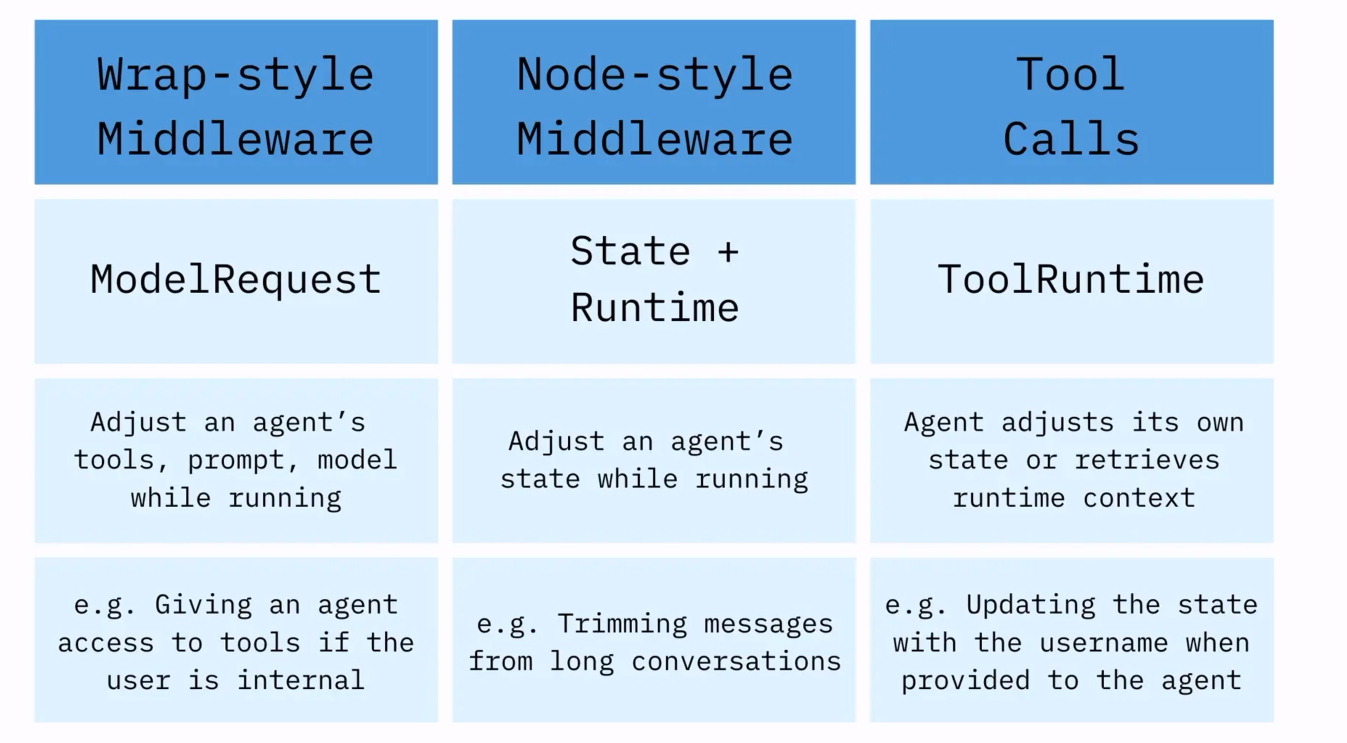